# Praktikum 2: Approximate Nearest Neighbor Menggunakan FAISS

In [1]:
!pip install faiss-cpu

   ---------------------------------------- 0.0/16.6 MB ? eta -:--:--
   --- ------------------------------------ 1.3/16.6 MB 9.5 MB/s eta 0:00:02
   -------- ------------------------------- 3.4/16.6 MB 9.7 MB/s eta 0:00:02
   ------------ --------------------------- 5.2/16.6 MB 9.6 MB/s eta 0:00:02
   ----------------- ---------------------- 7.1/16.6 MB 9.5 MB/s eta 0:00:02
   -------------------- ------------------- 8.7/16.6 MB 9.2 MB/s eta 0:00:01
   ------------------------- -------------- 10.5/16.6 MB 9.2 MB/s eta 0:00:01
   ------------------------------ --------- 12.6/16.6 MB 9.2 MB/s eta 0:00:01
   ----------------------------------- ---- 14.7/16.6 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------  16.5/16.6 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 16.6/16.6 MB 9.0 MB/s  0:00:01


Exact NN (Flat) indices: [[137 170 750]] distances: [[0.00013095 0.00077404 0.00079751]]
IVF+PQ indices: [[137 170 750]] distances: [[0.00012945 0.00079226 0.00080067]]
Waktu Exact: 0.2217 ms
Waktu IVF+PQ: 0.4299 ms


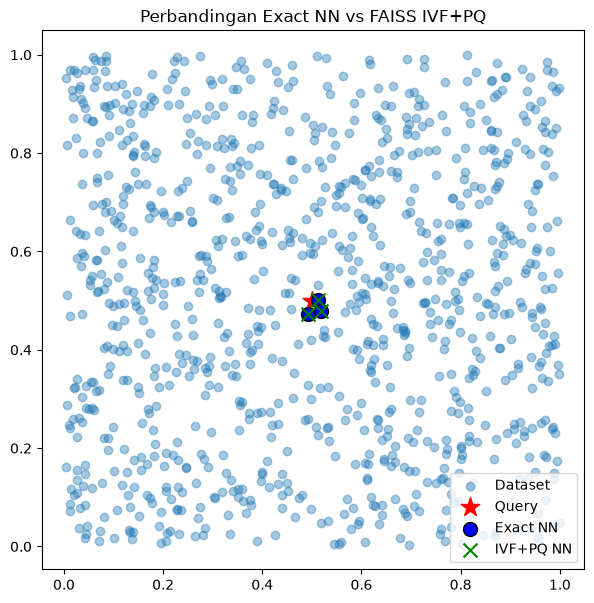

In [2]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import time

# 1. Buat dataset 2D sederhana
np.random.seed(42)
X = np.random.rand(1000, 2).astype('float32')  # 1000 titik 2D
query = np.array([[0.5, 0.5]], dtype='float32')  # query di tengah

# 2. Exact NN dengan IndexFlatL2 (brute force tapi cepat)
index_flat = faiss.IndexFlatL2(2)   # L2 = Euclidean distance
index_flat.add(X)

start = time.time()
D_flat, I_flat = index_flat.search(query, 3)  # cari 3 tetangga terdekat
end = time.time()
time_flat = end - start

# 3. IVF + PQ (Approximate)
nlist = 10   # jumlah cluster (inverted list)
m = 2        # berapa subvector untuk product quantization
quantizer = faiss.IndexFlatL2(2)   # dipakai IVF untuk cluster awal
index_ivfpq = faiss.IndexIVFPQ(quantizer, 2, nlist, m, 8)  # 8 bit per subvector

index_ivfpq.train(X)  # training centroid
index_ivfpq.add(X)

start = time.time()
D_ivfpq, I_ivfpq = index_ivfpq.search(query, 3)
end = time.time()
time_ivfpq = end - start

# 4. Print hasil
print("Exact NN (Flat) indices:", I_flat, "distances:", D_flat)
print("IVF+PQ indices:", I_ivfpq, "distances:", D_ivfpq)
print("Waktu Exact:", round(time_flat * 1000, 4), "ms")
print("Waktu IVF+PQ:", round(time_ivfpq * 1000, 4), "ms")

# 5. Visualisasi
plt.figure(figsize=(7, 7))
plt.scatter(X[:,0], X[:,1], alpha=0.4, label="Dataset")
plt.scatter(query[:,0], query[:,1], c='red', marker='*', s=200, label="Query")

# Tetangga dari Flat
plt.scatter(X[I_flat[0],0], X[I_flat[0],1], c='blue', s=100, edgecolor='k', label="Exact NN")

# Tetangga dari IVF+PQ
plt.scatter(X[I_ivfpq[0],0], X[I_ivfpq[0],1], c='green', marker='x', s=100, label="IVF+PQ NN")

plt.legend()
plt.title("Perbandingan Exact NN vs FAISS IVF+PQ")
plt.show()

In [3]:
def run_faiss_experiment(metric, n_data, dim, k=3):
    np.random.seed(42)
    X_exp = np.random.rand(n_data, dim).astype('float32')
    
    if metric == 'Inner Product':
        # Untuk Cosine/Inner Product, vektor perlu dinormalisasi (L2 normalization)
        faiss.normalize_L2(X_exp)
        query_exp = np.random.rand(1, dim).astype('float32')
        faiss.normalize_L2(query_exp)
        
        index_flat = faiss.IndexFlatIP(dim)
    else:
        query_exp = np.random.rand(1, dim).astype('float32')
        index_flat = faiss.IndexFlatL2(dim)

    # 1. Exact NN
    index_flat.add(X_exp)
    t0 = time.time()
    D_flat, I_flat = index_flat.search(query_exp, k)
    time_flat = (time.time() - t0) * 1000

    # 2. IVF+PQ (Approximate)
    nlist = int(np.sqrt(n_data)) if n_data > 1000 else 10
    m = dim if dim <= 2 else (5 if dim == 5 else 2)  # subvector pembagi
    
    if metric == 'Inner Product':
        quantizer = faiss.IndexFlatIP(dim)
    else:
        quantizer = faiss.IndexFlatL2(dim)
        
    index_ivfpq = faiss.IndexIVFPQ(quantizer, dim, nlist, m, 8)
    index_ivfpq.train(X_exp)
    index_ivfpq.add(X_exp)

    t0 = time.time()
    D_ivfpq, I_ivfpq = index_ivfpq.search(query_exp, k)
    time_ivfpq = (time.time() - t0) * 1000

    print(f"Metric: {metric:13s} | Data: {n_data:7d} | Dim: {dim}D | "
          f"Index Exact vs IVF+PQ: {list(I_flat[0])}, {list(I_ivfpq[0])} | "
          f"Waktu (ms): {time_flat:.4f} vs {time_ivfpq:.4f}")

print("=== HASIL EKSPERIMEN TABEL FAISS ===")
# Parameter variasi: Distance Metric, Jumlah Data (1000 vs 1jt), Dimensi (2D vs 5D)
run_faiss_experiment('Euclidean', 1000, 2)
run_faiss_experiment('Euclidean', 1000, 5)
run_faiss_experiment('Euclidean', 1000000, 2)
run_faiss_experiment('Euclidean', 1000000, 5)

run_faiss_experiment('Inner Product', 1000, 2)
run_faiss_experiment('Inner Product', 1000, 5)
run_faiss_experiment('Inner Product', 1000000, 2)
run_faiss_experiment('Inner Product', 1000000, 5)

=== HASIL EKSPERIMEN TABEL FAISS ===
Metric: Euclidean     | Data:    1000 | Dim: 2D | Index Exact vs IVF+PQ: [np.int64(112), np.int64(535), np.int64(777)], [np.int64(112), np.int64(777), np.int64(548)] | Waktu (ms): 0.4392 vs 0.0811
Metric: Euclidean     | Data:    1000 | Dim: 5D | Index Exact vs IVF+PQ: [np.int64(988), np.int64(780), np.int64(27)], [np.int64(988), np.int64(780), np.int64(27)] | Waktu (ms): 0.0761 vs 0.1802
Metric: Euclidean     | Data: 1000000 | Dim: 2D | Index Exact vs IVF+PQ: [np.int64(132774), np.int64(119034), np.int64(511191)], [np.int64(132774), np.int64(119034), np.int64(511191)] | Waktu (ms): 17.7822 vs 0.1695
Metric: Euclidean     | Data: 1000000 | Dim: 5D | Index Exact vs IVF+PQ: [np.int64(901095), np.int64(495168), np.int64(561017)], [np.int64(901095), np.int64(495168), np.int64(561017)] | Waktu (ms): 2.6338 vs 0.1414
Metric: Inner Product | Data:    1000 | Dim: 2D | Index Exact vs IVF+PQ: [np.int64(738), np.int64(183), np.int64(561)], [np.int64(738), np.i